In [2]:

#@title 1) Kurulum (~2-3 dk; derleme YOK, pytorch3d GEREKMEZ)
import os
if not os.path.exists('/content/MeshVTON'):
    !git clone https://github.com/SerhanTelatar/MeshVTON /content/MeshVTON
%cd /content/MeshVTON
!git pull

# Yalnız eksik paketler (torch/transformers/accelerate Colab'da hazır):
!pip -q install "diffusers>=0.34" "peft>=0.14" lpips einops sentencepiece trimesh smplx pyrender onnxruntime
# OSMesa için pyrender'ın yamalı PyOpenGL fork'u ŞART (pip PyOpenGL'i
# "No array-type handler" ctypes hatası veriyor):
!pip -q uninstall -y pyopengl PyOpenGL-accelerate > /dev/null 2>&1
!pip -q install "git+https://github.com/mmatl/pyopengl.git"
# 4D-Humans (HMR2 — gerçek poz + pred_cam kamerası; kamera kapısı bunsuz çalışmaz)
import importlib.util
if importlib.util.find_spec('hmr2') is None:
    !pip -q install "git+https://github.com/shubham-goel/4D-Humans.git"
# GL sistem kütüphaneleri (Colab imajında libGLU yok -> pyrender import hatası)
!apt-get -qq install -y libglu1-mesa libosmesa6 > /dev/null 2>&1
# EGL çalışıyorsa onu, yoksa OSMesa'yı (yazılımsal, her yerde çalışır) kullan:
import subprocess
_probe = subprocess.run(["python", "-c",
    'import os;os.environ["PYOPENGL_PLATFORM"]="egl";'
    'import pyrender;r=pyrender.OffscreenRenderer(16,16);r.delete();print("egl-ok")'],
    capture_output=True, text=True)
os.environ['PYOPENGL_PLATFORM'] = 'egl' if 'egl-ok' in _probe.stdout else 'osmesa'
print('GL platform:', os.environ['PYOPENGL_PLATFORM'])

# IDM-VTON yalnız KIŞI ön-işlemesi için (parsing onnx + openpose ckpt); densepose/detectron2 YOK
if not os.path.exists('/content/IDM-VTON'):
    !git clone -q https://github.com/yisol/IDM-VTON /content/IDM-VTON
# Ön-işleme model dosyaları: wget DEĞİL hf_hub_download (LFS'i doğru indirir; wget
# HF'ten HTML hata sayfası kaydedip INVALID_PROTOBUF'a yol açabiliyor)
import shutil
from huggingface_hub import hf_hub_download
for repo_path in ('humanparsing/parsing_atr.onnx',
                  'humanparsing/parsing_lip.onnx',
                  'openpose/ckpts/body_pose_model.pth'):
    local = f'/content/IDM-VTON/ckpt/{repo_path}'
    if not (os.path.exists(local) and os.path.getsize(local) > 1_000_000):
        os.makedirs(os.path.dirname(local), exist_ok=True)
        shutil.copy(hf_hub_download('yisol/IDM-VTON', repo_path), local)
    assert os.path.getsize(local) > 1_000_000, f'bozuk indirme: {local}'

# FLUX.1 dev gated: Colab Secrets'a HF_TOKEN ekleyin (soldaki anahtar simgesi, Notebook access açık)
from google.colab import userdata
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
print('Kurulum OK')

Cloning into '/content/MeshVTON'...
remote: Enumerating objects: 914, done.
remote: Counting objects: 100% (421/421), done.
remote: Compressing objects: 100% (280/280), done.
remote: Total 914 (delta 265), reused 278 (delta 127), pack-reused 493 (from 1)
Receiving objects: 100% (914/914), 10.32 MiB | 31.45 MiB/s, done.
Resolving deltas: 100% (547/547), done.
/content/MeshVTON
Already up to date.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 67.8 MB/s eta 0:00:00
  Preparing

humanparsing/parsing_atr.onnx:   0%|          | 0.00/267M [00:00<?, ?B/s]

humanparsing/parsing_lip.onnx:   0%|          | 0.00/267M [00:00<?, ?B/s]

openpose/ckpts/body_pose_model.pth:   0%|          | 0.00/209M [00:00<?, ?B/s]

Kurulum OK


In [3]:
#@title 2) Veri — Drive/MeshVTON düzenine göre (images.zip, garments_3d.zip, smplx/, smplx_params.zip)
import os, sys
sys.path.insert(0, '/content/MeshVTON/v2')
from google.colab import drive
drive.mount('/content/drive')
D = '/content/drive/MyDrive/MeshVTON'

# zip'lerin İÇİNDE üst klasör var (images/, garments_3d/) -> bir üst hedefe aç:
!mkdir -p /content/MeshVTON/data/raw
!unzip -q -n $D/images.zip      -d /content/MeshVTON/data/raw    # -> data/raw/images/
!unzip -q -n $D/garments_3d.zip -d /content/MeshVTON/data        # -> data/garments_3d/

# SMPL-X modeli (Drive: MeshVTON/smplx/SMPLX_NEUTRAL.*) — 'checkpoints' klasörünü BİZ oluşturuyoruz,
# Drive'da olması gerekmiyor:
!mkdir -p /content/MeshVTON/checkpoints/pretrained/smplx
!cp $D/smplx/SMPLX_NEUTRAL.* /content/MeshVTON/checkpoints/pretrained/smplx/
os.environ['SMPLX_MODEL_DIR'] = '/content/MeshVTON/checkpoints/pretrained/smplx'

# Poz bankası: v1'in kişi başına SMPL-X tahminleri (sentetik veri gerçek pozlarla üretilsin)
!unzip -q -n $D/smplx_params.zip -d /content/MeshVTON/data/smplx_params

# HMR2 ağırlıkları (bir kez ~3.5GB) + SMPL neutral pkl (Drive: MeshVTON/smpl/)
import glob, shutil
from meshvton2.conditioning.body import _patch_torch_load_weights_only
import torch as _torch; _patch_torch_load_weights_only(_torch)
from hmr2.models import download_models
from hmr2.configs import CACHE_DIR_4DHUMANS
download_models(CACHE_DIR_4DHUMANS)
smpl_dir = f"{CACHE_DIR_4DHUMANS}/data/smpl"; os.makedirs(smpl_dir, exist_ok=True)
cands = glob.glob(f'{D}/smpl/*neutral*lbs*.pkl') + glob.glob(f'{D}/smpl/SMPL_NEUTRAL.pkl')
assert cands, "SMPL neutral pkl yok -> Drive/MeshVTON/smpl/ (smplify.is.tue.mpg.de)"
shutil.copy(cands[0], f"{smpl_dir}/SMPL_NEUTRAL.pkl")
print('HMR2 + SMPL hazır')

# doğrulama
!ls /content/MeshVTON/data/raw/images | head -3
!find /content/MeshVTON/data/garments_3d -name "*.obj" | wc -l
!ls /content/MeshVTON/checkpoints/pretrained/smplx
!ls /content/MeshVTON/data/smplx_params | head -3

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)



Extracting file: hmr2_data.tar.gz
HMR2 + SMPL hazır
00000_00.jpg
00001_00.jpg
00002_00.jpg
1636
SMPLX_NEUTRAL.npz
00000_00.npz
00001_00.npz
00002_00.npz


In [7]:
!pip -q uninstall -y torchao
%cd /content/MeshVTON
!git pull

/content/MeshVTON
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 7 (delta 6), reused 7 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 1.21 KiB | 1.21 MiB/s, done.
From https://github.com/SerhanTelatar/MeshVTON
   22fb9fc..1fca1d6  main       -> origin/main
Updating 22fb9fc..1fca1d6
Fast-forward
 v2/configs/stage1_singleview.yaml | 4 +++-
 v2/scripts/train_stage1.py        | 4 ++++
 2 files changed, 7 insertions(+), 1 deletion(-)


In [8]:

#@title 3) TEK-KOŞU pipeline — Run all yeter; her aşama resume'ludur
NUM_SYNTH     = 2000   #@param {type:"integer"}   # tam üretim; duman için 5-50 kullanın
VITONHD_LIMIT = 2000   #@param {type:"integer"}
TRAIN_STEPS   = 4000  #@param {type:"integer"}
UNTIL         = "eval" #@param ["check","camera","smoke","synth","vitonhd","baseline","train","eval"]

# Colab koparsa: runtime'ı yeniden başlat -> Run all -> kaldığı yerden devam eder
# (sentetik üretim örnek sayısını sayar, eğitim latest.pt'den resume eder).
!python v2/scripts/colab_pipeline.py \
    --idm-repo /content/IDM-VTON \
    --num $NUM_SYNTH --vitonhd-limit $VITONHD_LIMIT --train-steps $TRAIN_STEPS \
    --until $UNTIL


== 1/8 ortam kontrolü
repo: 1fca1d6 v2: torch.compile kapatıldı — checkpointing'i etkisizleştirip ilk backward'da OOM (ölçüldü)
GPU: NVIDIA A100-SXM4-80GB (85 GB)
bağımlılıklar tamam

== 2/8 kamera doğrulama kapısı (IoU >= 0.70)
$ python v2/scripts/validate_camera.py --idm-repo /content/IDM-VTON --limit 5
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Lightning automatically upgraded your loaded checkpoint from v1.8.1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/4DHumans/logs/train/multiruns/hmr2/0/checkpoints/epoch=35-step=1000000.ckpt`
100% 1/1 [00:00<00:00,  1.53it/s]
100% 1/1 [00:00<00:00,  1.74it/s]
/usr/local/lib/python3.12/dist-packages/hmr2/utils/geometry.py:61

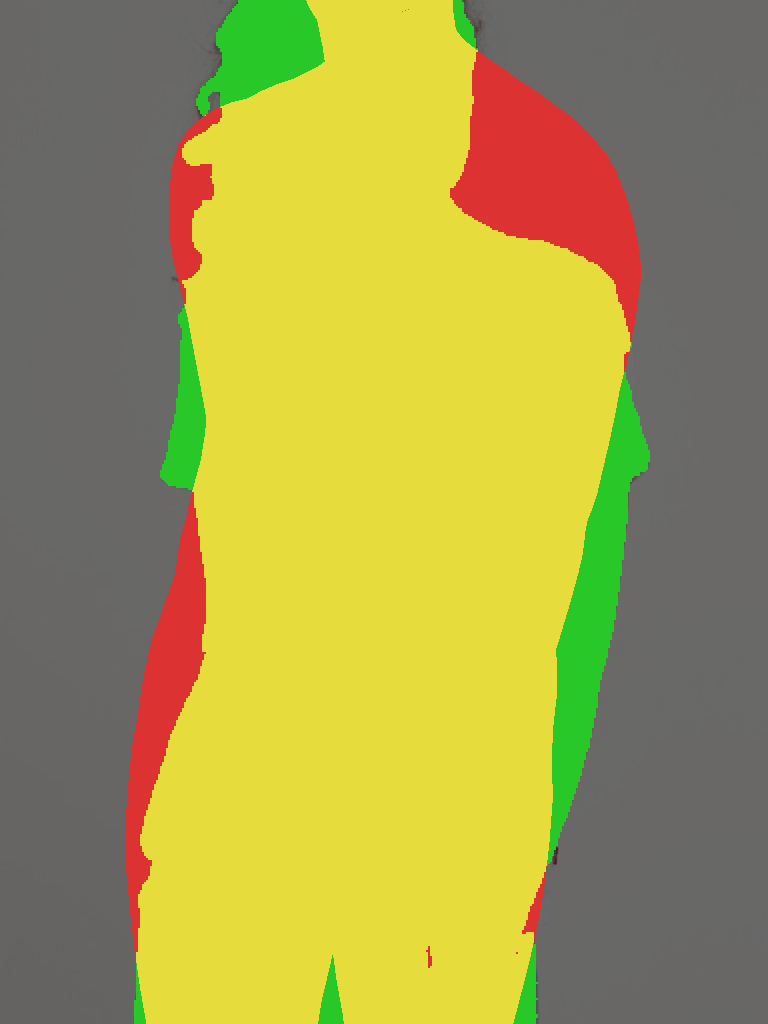

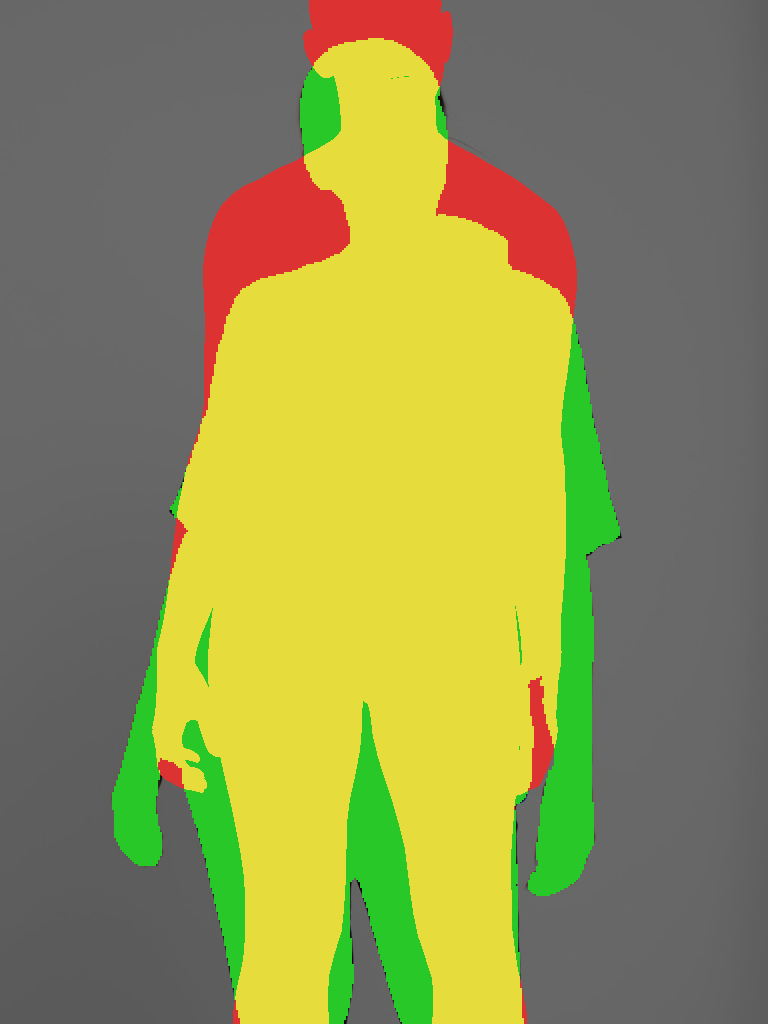

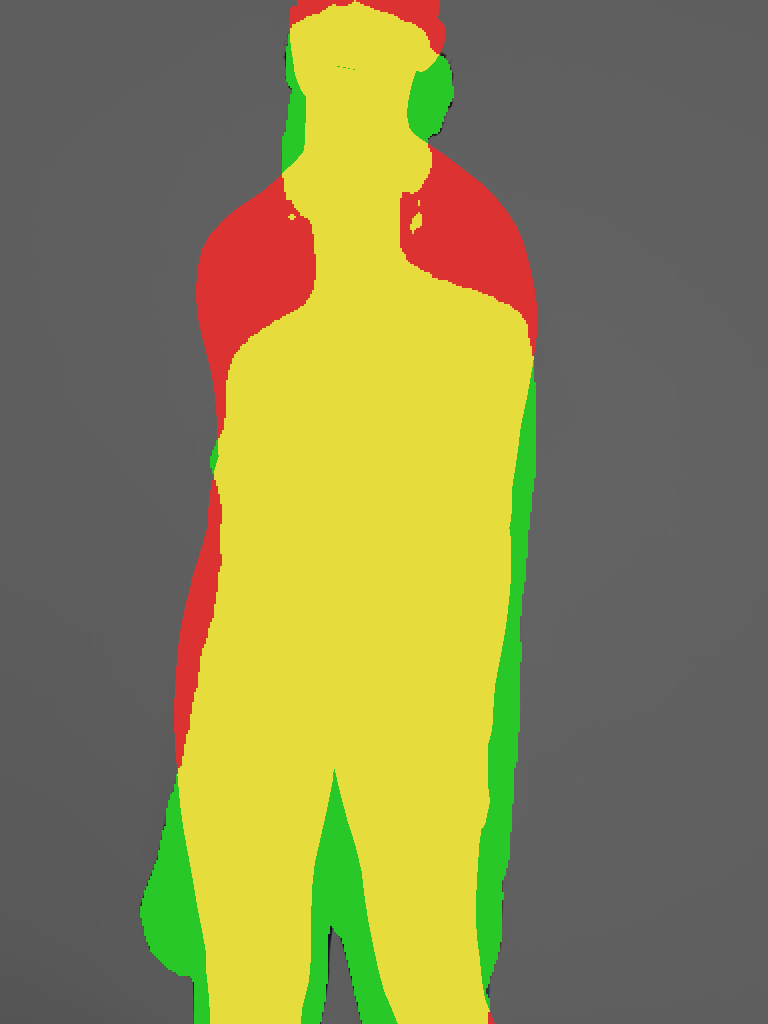

## Sentetik QA: s000_000000 (view_180 = arka görünüm mü?)

**0°**

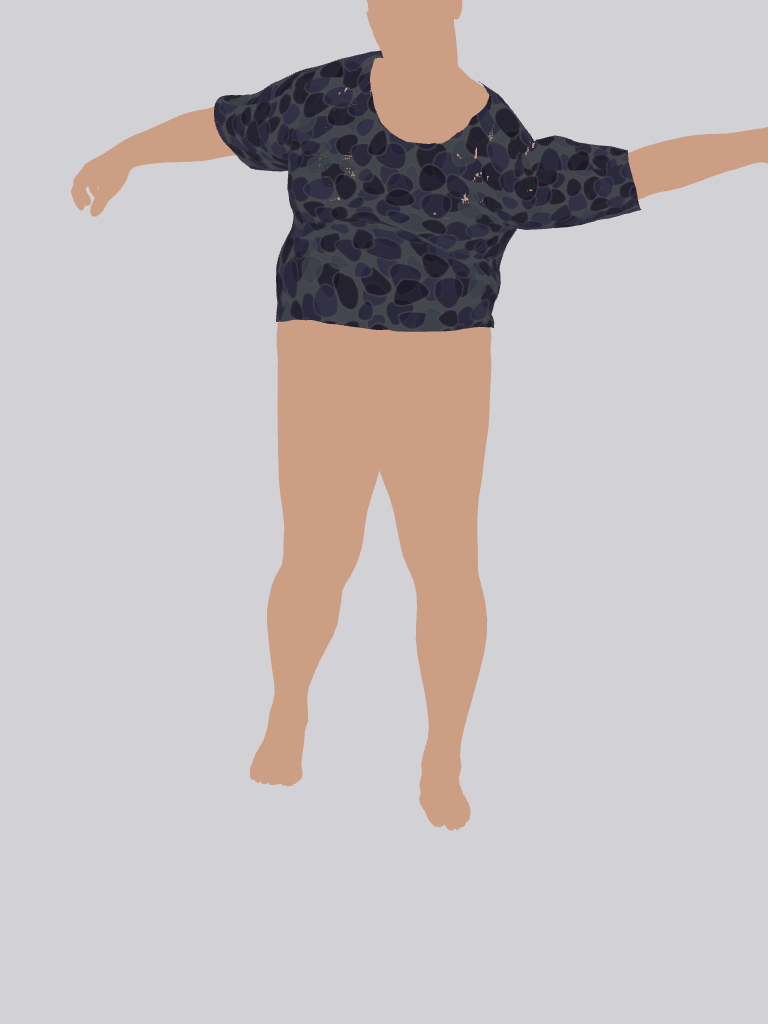

**90°**

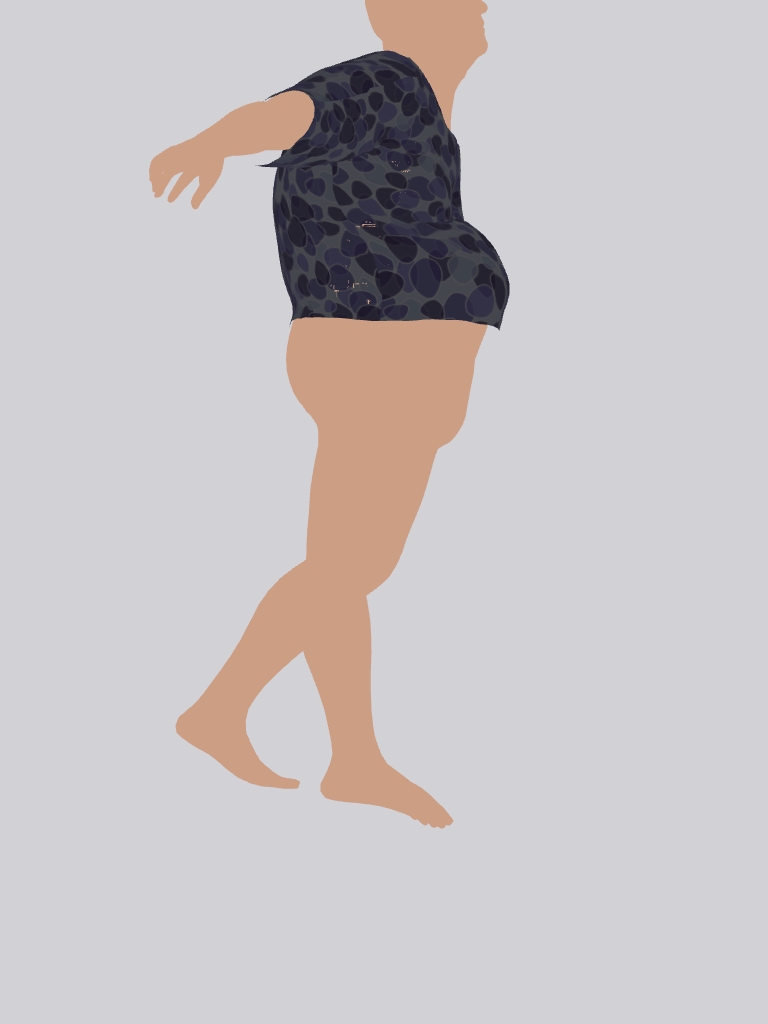

**180°**

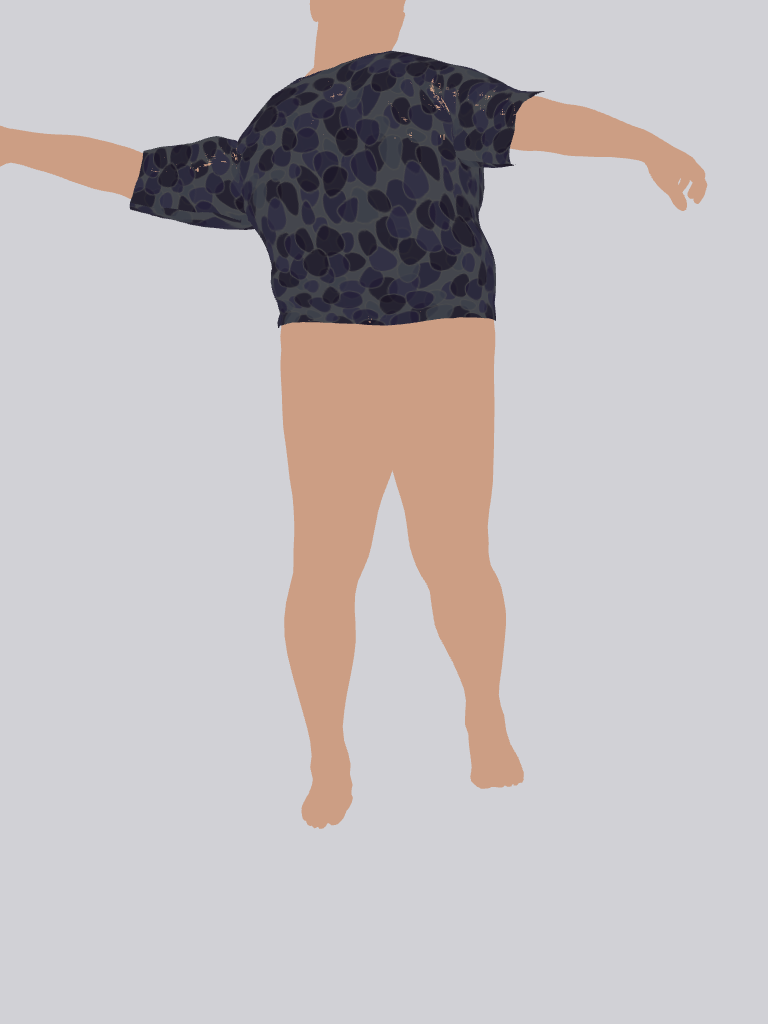

**270°**

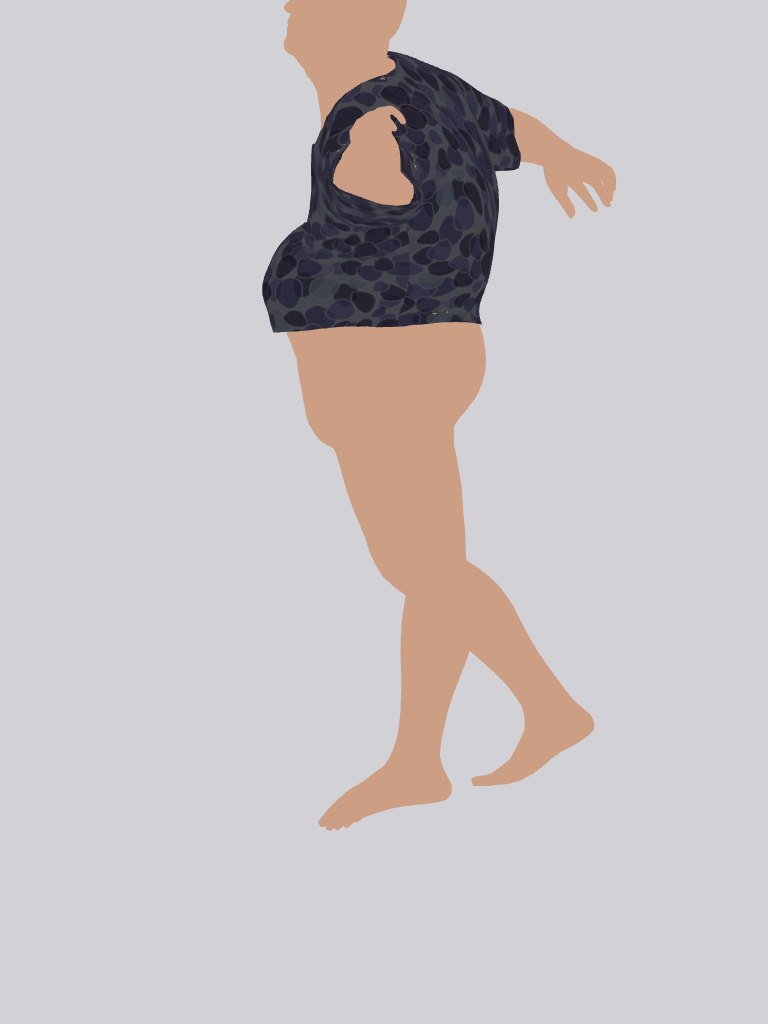

In [9]:

#@title 4) Sonuçlar (Drive: MeshVTON/v2_outputs altında da var)
from IPython.display import Image as I, display, Markdown
import pathlib

for md in sorted(pathlib.Path("v2/eval_results").glob("*.md")):
    display(Markdown(f"## {md.stem}"), Markdown(md.read_text()))
for grid in sorted(pathlib.Path("v2/eval_results").glob("*_grid.png")):
    display(I(str(grid), width=900))

# kamera doğrulama overlay'leri + sentetik QA
for f in sorted(pathlib.Path("v2/eval_results/camera_validation").glob("*.png"))[:3]:
    display(I(str(f), width=280))
qa = sorted(pathlib.Path("v2/eval_results/synth_qa").glob("s*/"))
if qa:
    s = qa[0]
    display(Markdown(f"## Sentetik QA: {s.name} (view_180 = arka görünüm mü?)"))
    for v in ("000", "090", "180", "270"):
        gt = s / f"view_{v}" / "gt.png"
        if gt.exists():
            display(Markdown(f"**{int(v)}°**"), I(str(gt), width=200))

In [10]:
# 1) Mesh geometri teşhisi: yassı mı, kaç parça?
import numpy as np, trimesh, glob
for p in sorted(glob.glob('/content/MeshVTON/data/garments_3d/upper_body/*/mesh.obj'))[:5] + \
         sorted(glob.glob('/content/MeshVTON/data/garments_3d/dresses/*/mesh.obj'))[:2]:
    m = trimesh.load(p, force='mesh', process=False)
    v = np.asarray(m.vertices)
    ext = np.round(v.max(0) - v.min(0), 3)
    parts = len(m.split(only_watertight=False))
    print(f"{p.split('/')[-2]:24s} boyutlar={ext} verts={len(v)} parça={parts}")

# 2) Bir giysi klasöründe başka ne var? (belki 3D-drape'li ayrı dosya vardır)
!ls -la /content/MeshVTON/data/garments_3d/upper_body/00259_Top/
!ls -la /content/MeshVTON/data/garments_3d/dresses/00022_Dress/

00047_Top                boyutlar=[0.395 0.319 0.403] verts=1866 parça=1
00111_Tshirt             boyutlar=[0.825 0.314 0.479] verts=4957 parça=2
00126_Tshirt             boyutlar=[0.747 0.168 0.326] verts=3933 parça=2
00139_Top                boyutlar=[0.305 0.189 0.217] verts=987 parça=1
00178_Top                boyutlar=[0.268 0.202 0.353] verts=1115 parça=2
00022_Dress              boyutlar=[0.436 0.342 1.142] verts=7404 parça=2
00078_Dress              boyutlar=[0.639 0.461 1.035] verts=9085 parça=2
total 5640
drwxr-xr-x   2 root root    4096 Jul  5 12:01 .
drwxr-xr-x 220 root root   12288 Jul  5 12:02 ..
-rw-rw-rw-   1 root root  182296 Apr 13  2021 info.mat
-rw-rw-rw-   1 root root  258935 Apr 13  2021 mesh.obj
-rw-rw-rw-   1 root root 5310671 Apr 13  2021 texture.png
total 5416
drwxr-xr-x   2 root root    4096 Jul  5 12:00 .
drwxr-xr-x 184 root root    4096 Jul  5 12:01 ..
-rw-rw-rw-   1 root root  181912 Apr 13  2021 info.mat
-rw-rw-rw-   1 root root  926620 Apr 13  2021 mesh.

In [14]:
!python v2/scripts/eval_checkpoint.py \
    --checkpoint /content/drive/MyDrive/MeshVTON/v2_outputs/stage1/final.pt \
    --idm-repo /content/IDM-VTON --limit 6

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Lightning automatically upgraded your loaded checkpoint from v1.8.1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/4DHumans/logs/train/multiruns/hmr2/0/checkpoints/epoch=35-step=1000000.ckpt`
100% 1/1 [00:00<00:00,  2.60it/s]
100% 1/1 [00:00<00:00,  2.89it/s]
/usr/local/lib/python3.12/dist-packages/hmr2/utils/geometry.py:61: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp

/content/MeshVTON


## 00000_00_upper_body__00111_Tshirt_000

**EĞİTİLMİŞ + kontrol AÇIK** — üst: giysi referansı, alt: sonuç

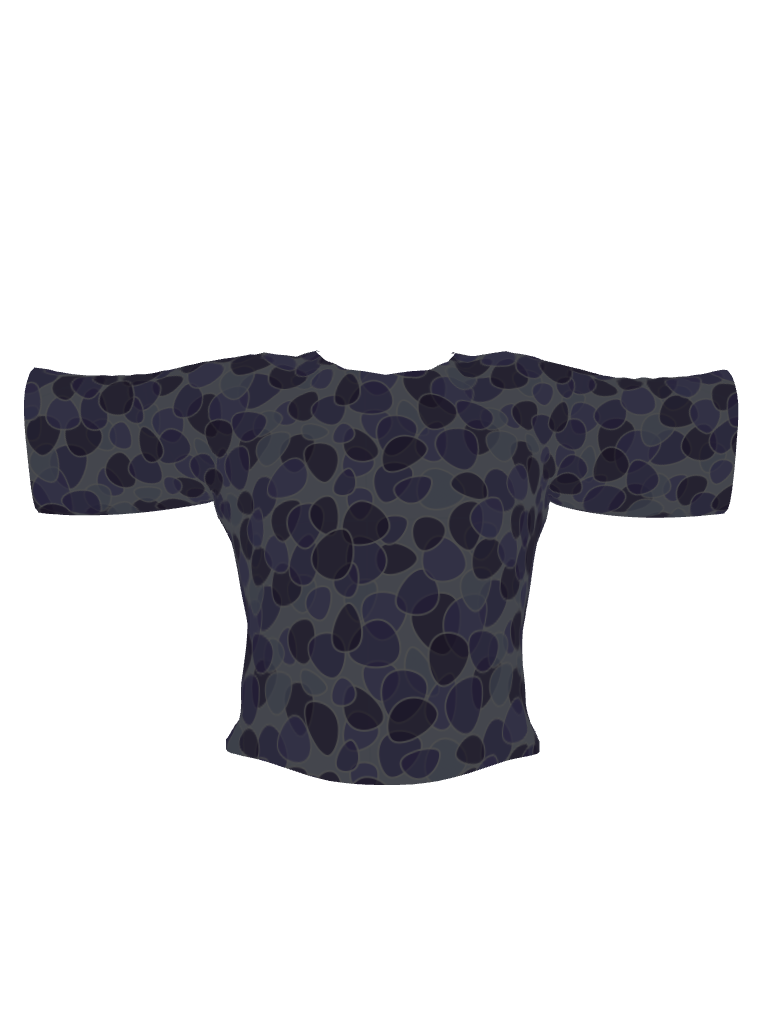

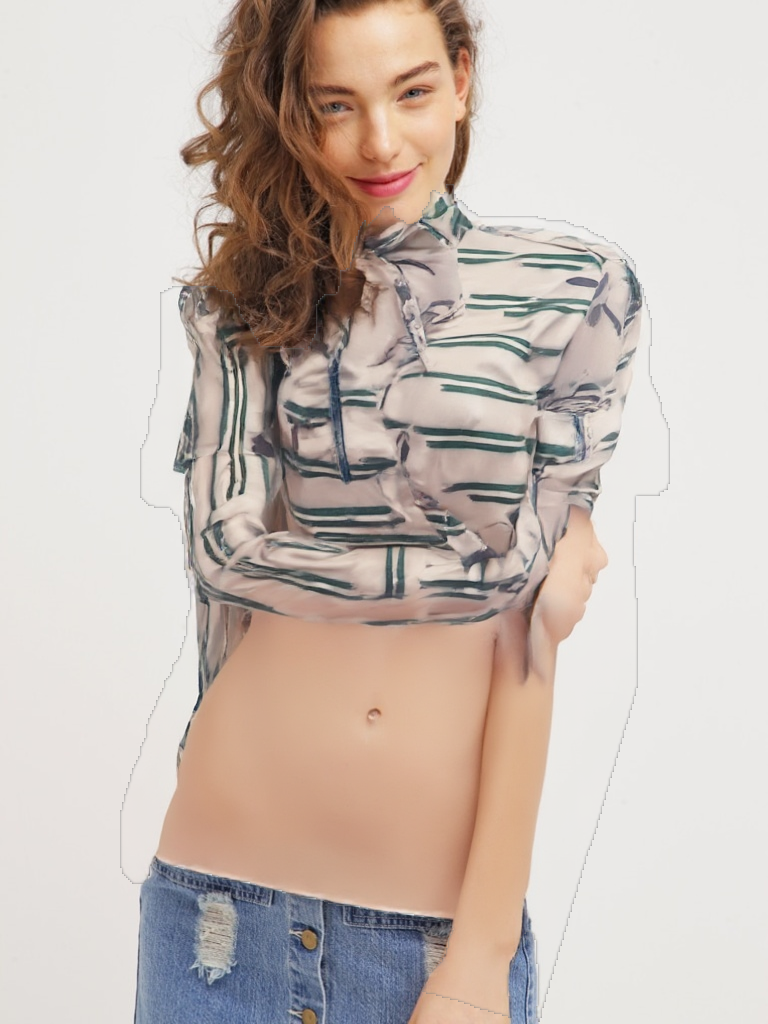

**EĞİTİLMİŞ + kontrol KAPALI** — üst: giysi referansı, alt: sonuç

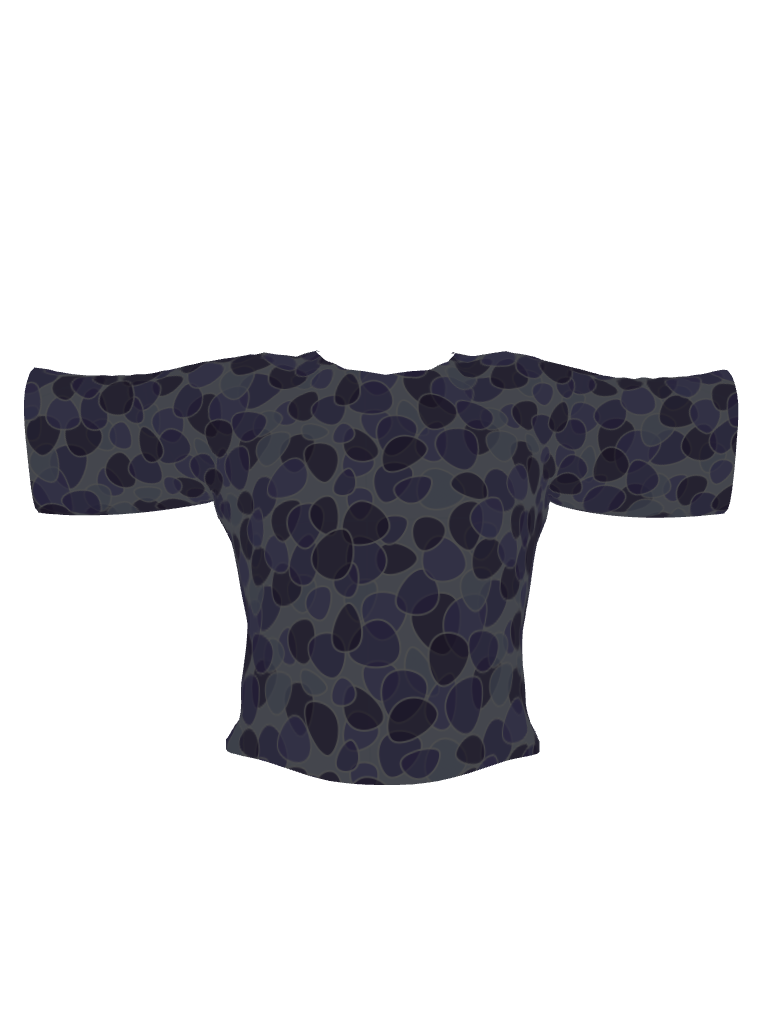

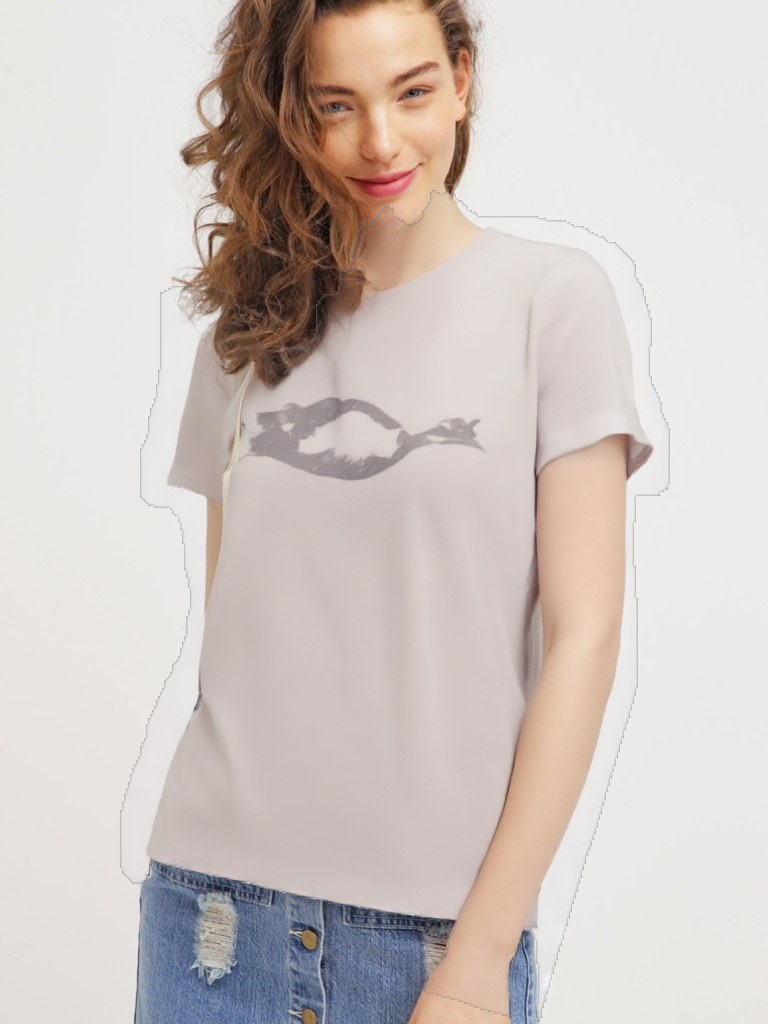

## 00000_00_upper_body__00259_Top_000

**EĞİTİLMİŞ + kontrol AÇIK** — üst: giysi referansı, alt: sonuç

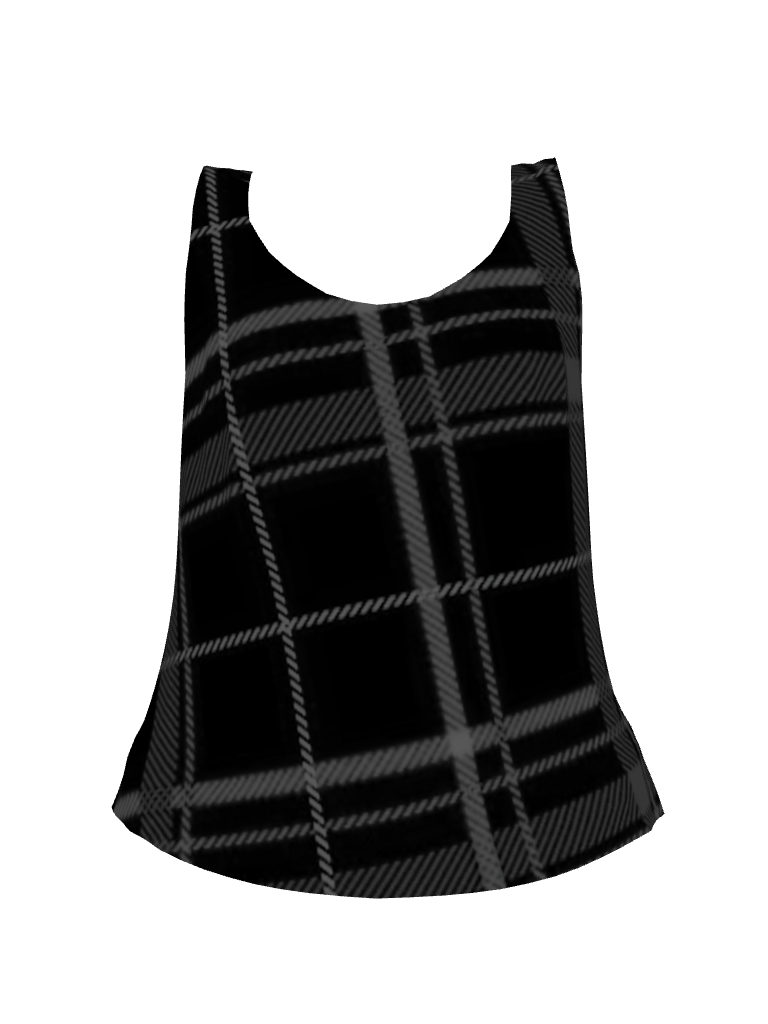

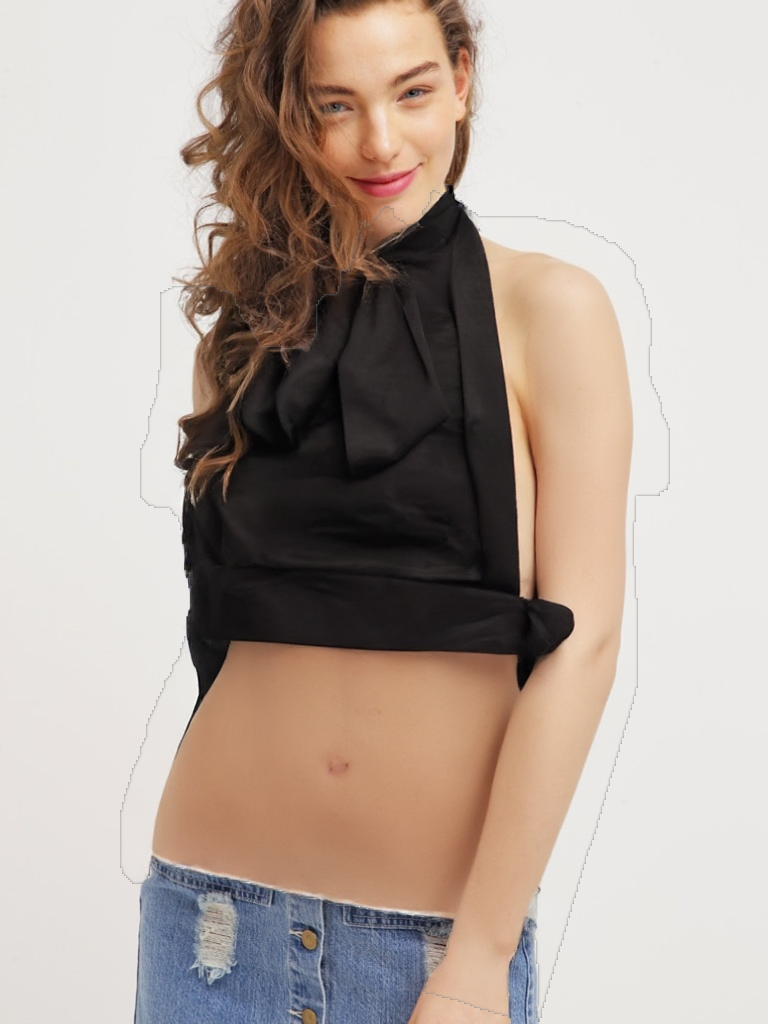

**EĞİTİLMİŞ + kontrol KAPALI** — üst: giysi referansı, alt: sonuç

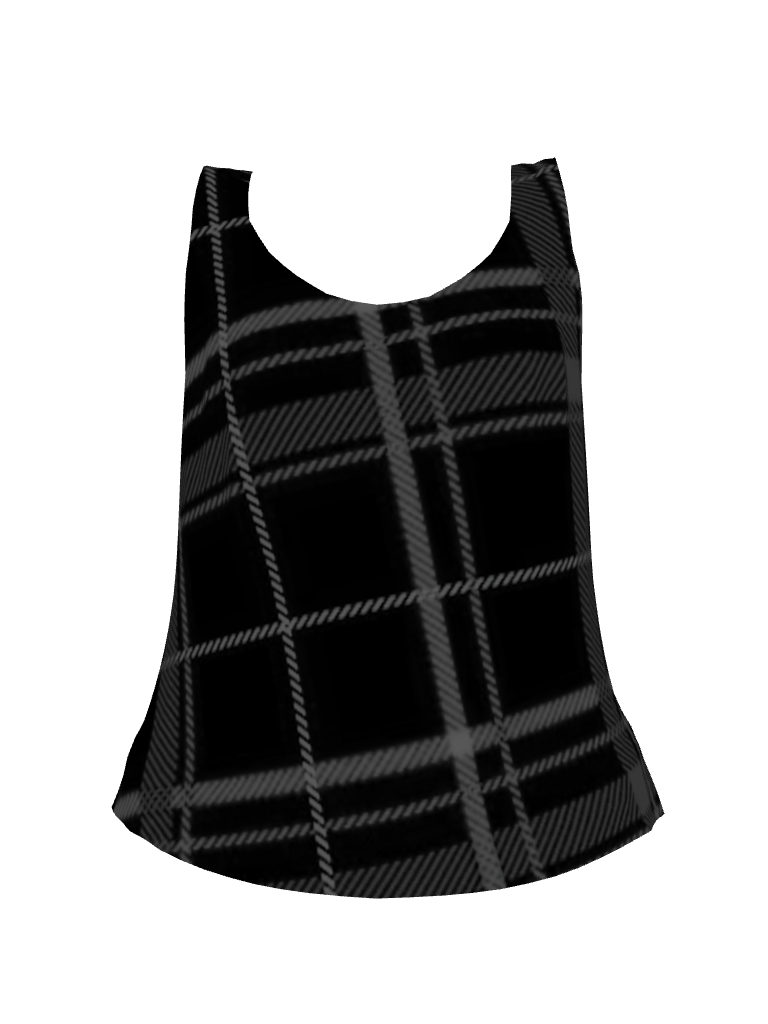

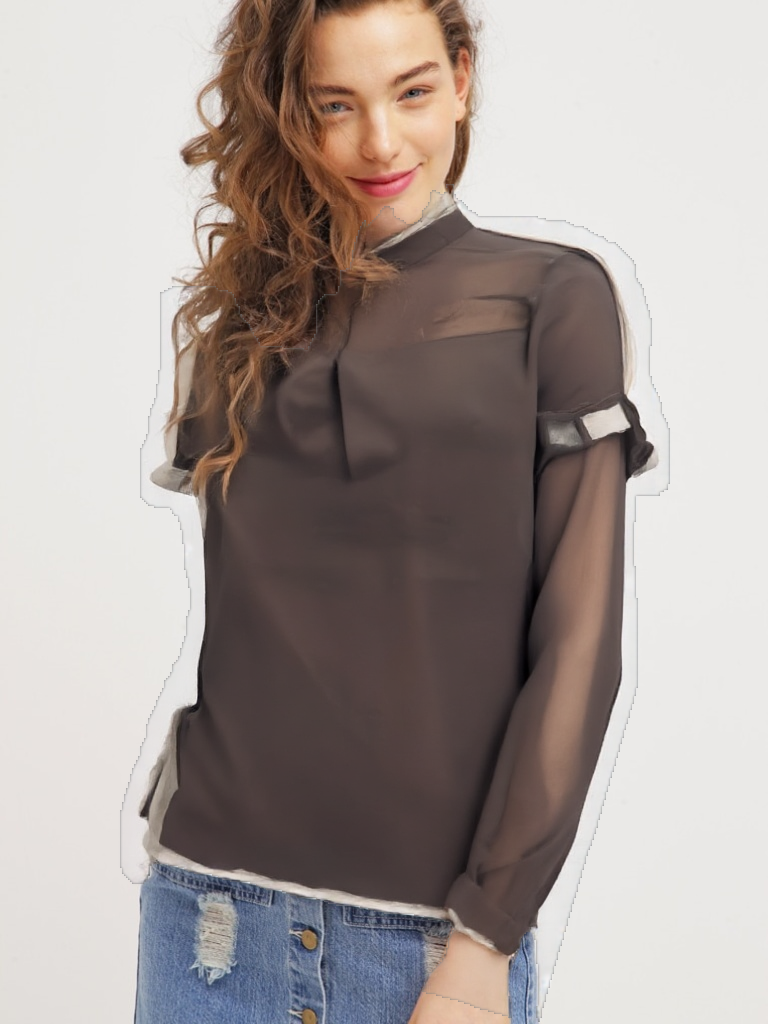

## 00000_00_upper_body__00436_Top_000

**EĞİTİLMİŞ + kontrol AÇIK** — üst: giysi referansı, alt: sonuç

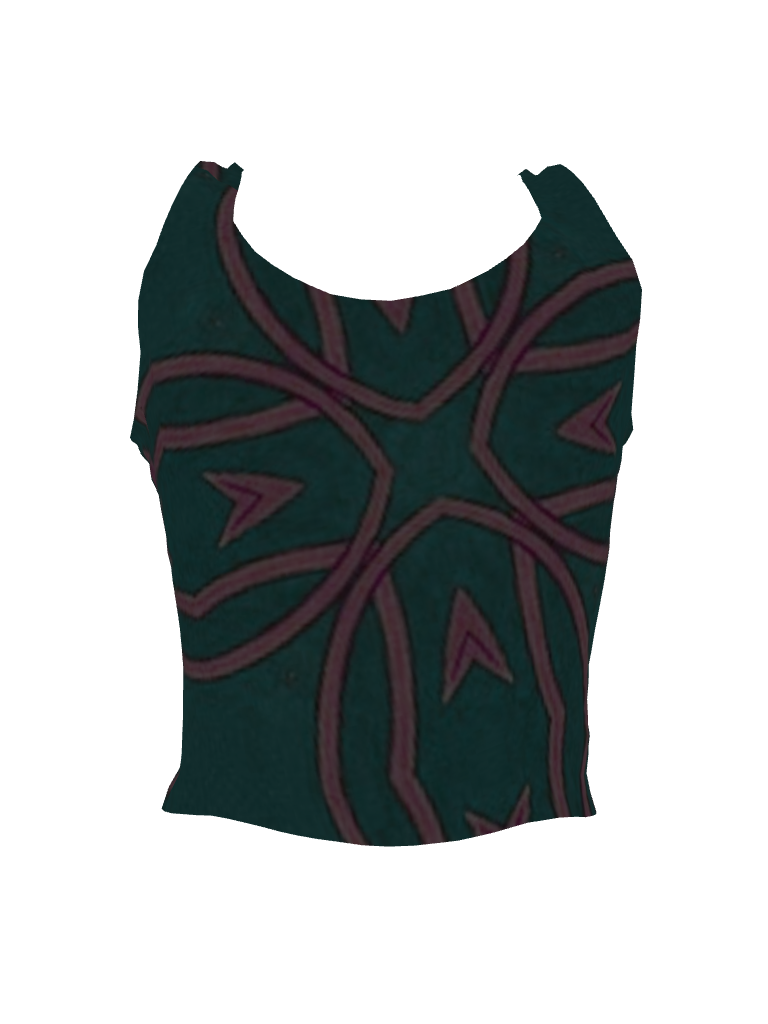

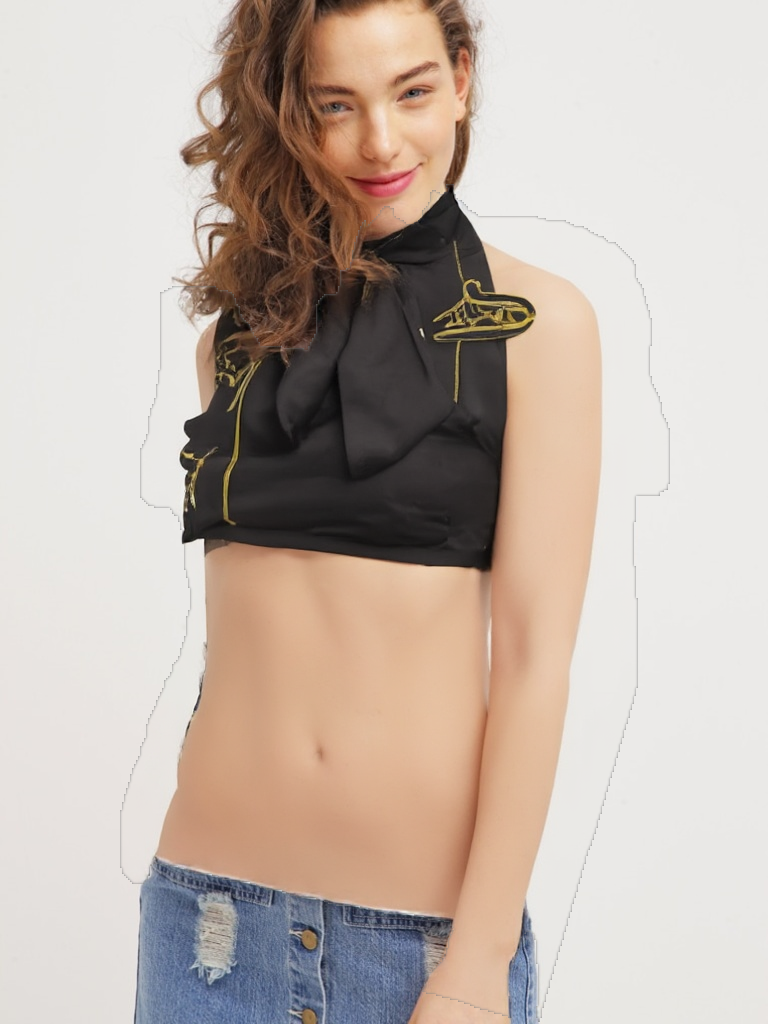

**EĞİTİLMİŞ + kontrol KAPALI** — üst: giysi referansı, alt: sonuç

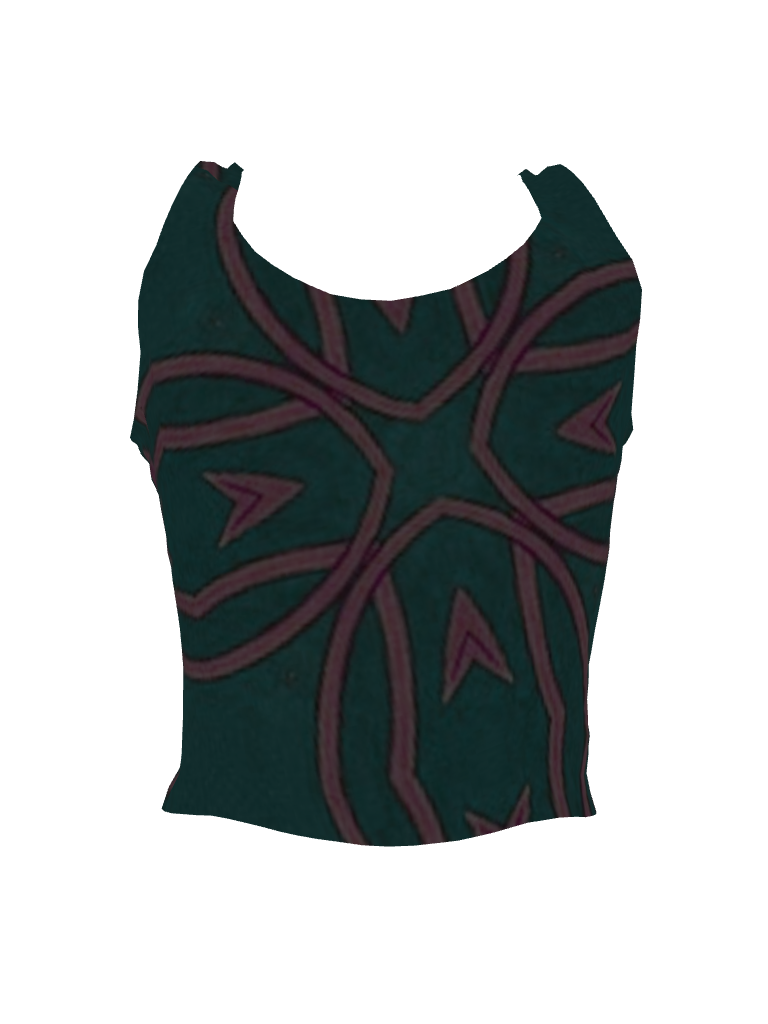

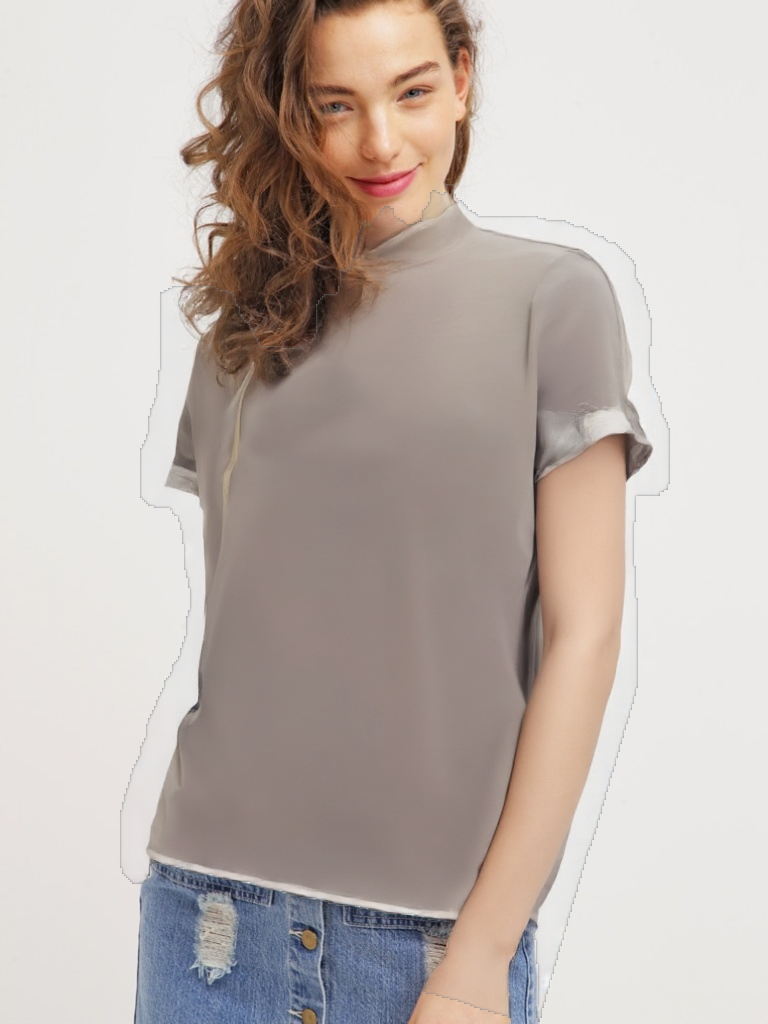

In [15]:
%cd /content/MeshVTON
from IPython.display import display, Markdown, Image as I
import pathlib

base = pathlib.Path('v2/eval_results')
combos = ["00000_00_upper_body__00111_Tshirt_000",
          "00000_00_upper_body__00259_Top_000",
          "00000_00_upper_body__00436_Top_000"]
for c in combos:
    display(Markdown(f"## {c}"))
    for tag, ad in [("ckpt_control_on", "EĞİTİLMİŞ + kontrol AÇIK"),
                    ("ckpt_control_off", "EĞİTİLMİŞ + kontrol KAPALI"),
                    ("phase1_fill_spatial", "EĞİTİMSİZ taban çizgisi")]:
        p = base / tag / "preds" / f"{c}.png"
        r = base / tag / "preds" / f"{c}.ref.png"
        if p.exists():
            display(Markdown(f"**{ad}** — üst: giysi referansı, alt: sonuç"))
            if r.exists(): display(I(str(r), width=160))
            display(I(str(p), width=260))

In [9]:
%cd /content/MeshVTON
!git pull
!python v2/scripts/tune_inference.py \
    --checkpoint /content/drive/MyDrive/MeshVTON/v2_outputs/stage1/final.pt \
    --idm-repo /content/IDM-VTON \
    --guidances 1 3.5 7.5 15 30 --combos 3

/content/MeshVTON
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 6 (delta 5), reused 6 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 1.18 KiB | 1.18 MiB/s, done.
From https://github.com/SerhanTelatar/MeshVTON
   29d4161..bf74855  main       -> origin/main
Updating 29d4161..bf74855
Fast-forward
 v2/meshvton2/model/lora.py | 17 +++++++++++++++++
 1 file changed, 17 insertions(+)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Lightning automatically upgraded your loaded checkpoint from v1.8.1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/4DHumans/logs/train/

In [6]:
%cd /content/MeshVTON
!python v2/scripts/build_golden_set.py \
    --vitonhd-test data/raw/images --garments data/garments_3d

/content/MeshVTON
UYARI: --person-list verilmedi; eşit aralıklı otomatik seçim yapıldı.
Golden set poz çeşitliliği (yan/¾) ve VITON-dışı 2-3 foto için ELLE küratörlük ister:
  seçimi v2/configs/golden_persons.txt'e yazıp düzenleyin.
OK: 20 kişi × 5 giysi × 4 açı = 400 değerlendirme öğesi
Manifest: /content/MeshVTON/v2/data/golden/manifest.json (commit'lenir; görüntüler gitignored)


In [7]:
%cd /content/MeshVTON
!mkdir -p data/raw/images data/garments_3d
!unzip -q -n /content/drive/MyDrive/MeshVTON/images.zip      -d data/raw/images
!unzip -q -n /content/drive/MyDrive/MeshVTON/garments_3d.zip -d data
!ls data/raw/images | head -2 ; find data/garments_3d -name '*.obj' | head -2

/content/MeshVTON
00000_00.jpg
00001_00.jpg
data/garments_3d/lower_body/07325_Trousers/mesh.obj
data/garments_3d/lower_body/07597_Trousers/mesh.obj
